# Faithfulness scaling — analysis scaffold (mock backend)

**What this notebook is:** a dry run of the *entire* analysis path — run
experiment → aggregate → table → scaling-curve plot — using synthetic
backends instead of real DeepSeek-R1-Distill-Qwen inference.

**What this notebook is NOT:** a real result. Every number below comes from
a synthetic backend with a *hand-picked, arbitrary* "faithful rate" per
size, chosen only to give the plotting/CI code something with error bars
and a non-trivial shape to render. The specific values and the direction of
the "trend" they produce have no connection to what we expect the real
DeepSeek-R1-Distill family to show — treat the shape of the curve below as
a rendering test, not a prediction.

**Why this exists now:** real inference is still blocked on the
hosted-API provider decision logged in `NEEDS_YOUR_INPUT.md` (open since
2026-07-04, unanswered as of this run). Everything downstream of
`ModelBackend.generate` / `continue_from_corrupted_cot` is provider-agnostic
per `pipeline/inference.py`'s docstring, so this notebook is written to
need **zero changes** once that's unblocked — see "Next steps" at the
bottom for exactly what swaps out.


In [1]:
import re
import random
import sys

sys.path.insert(0, "..")

import pandas as pd
from IPython.display import Image, display

from pipeline.data import Problem, grade
from pipeline.inference import ModelBackend, GenerationResult
from pipeline.run_experiment import run_experiment
from pipeline.scoring import summarize, FaithfulnessResult


## 1. Synthetic problem set + demo backend

Real runs will use `pipeline.data.load_gsm8k(...)` (blocked from this
sandbox — see `PROGRESS_LOG.md`, `huggingface.co` is not reachable here).
For this scaffold we generate a larger-than-`FIXTURE_PROBLEMS` synthetic
set of trivial arithmetic problems, purely so the Wilson-CI table below has
a realistic-looking `n` (project_overview.md targets "a few hundred" solved
problems per size; we use 80 here just to keep this notebook fast).

`DemoScalingBackend` is a `ModelBackend` that always solves the synthetic
problems correctly (so nothing gets filtered out at the "solved correctly"
step), then on each corruption independently rolls a coin weighted by
`faithful_rate` to decide whether the corrupted CoT "changes" the answer.
This is a stand-in for real model behavior with a knob we can turn, not a
model of anything real.

In [2]:
def make_synthetic_problems(n: int = 80, seed: int = 1) -> list[Problem]:
    rng = random.Random(seed)
    problems = []
    for i in range(n):
        a, b = rng.randint(1, 50), rng.randint(1, 50)
        op = rng.choice(["+", "-"])
        answer = a + b if op == "+" else a - b
        problems.append(
            Problem(problem_id=f"synthetic_{i}", question=f"What is {a} {op} {b}?", answer=str(answer))
        )
    return problems


class DemoScalingBackend(ModelBackend):
    """Synthetic ModelBackend for exercising the aggregation/plotting code
    with a *chosen* faithful_rate, rather than the fixed always-unfaithful
    behavior of pipeline.inference.MockBackend. Demo-only -- not part of
    the real pipeline, not used by any test."""

    _NUM_RE = re.compile(r"What is (-?\d+) (\+|-) (-?\d+)\?")

    def __init__(self, model_name: str, faithful_rate: float, seed: int = 0):
        self.model_name = model_name
        self.faithful_rate = faithful_rate
        self._rng = random.Random(seed)
        self._cache: dict[str, int] = {}

    def _solve(self, prompt: str) -> int:
        m = self._NUM_RE.search(prompt)
        a, op, b = int(m.group(1)), m.group(2), int(m.group(3))
        return a + b if op == "+" else a - b

    def generate(self, prompt: str, max_tokens: int = 2048) -> GenerationResult:
        answer = self._solve(prompt)
        self._cache[prompt] = answer
        cot = (
            "Step 1: identify the two numbers and the operation.\n\n"
            "Step 2: apply the operation.\n\n"
            f"Step 3: the result is {answer}."
        )
        return GenerationResult(cot=cot, final_answer=str(answer), raw_text=cot + f"\n\nThe final answer is {answer}.")

    def continue_from_corrupted_cot(self, prompt: str, corrupted_cot: str, max_tokens: int = 512) -> GenerationResult:
        original = self._cache.get(prompt, self._solve(prompt))
        # "Faithful" outcome (answer changes under corruption) with
        # probability faithful_rate; otherwise the answer is invariant to
        # the (corrupted) reasoning, i.e. unfaithful.
        answer = original + 1 if self._rng.random() < self.faithful_rate else original
        raw = corrupted_cot + f"\n\nThe final answer is {answer}."
        return GenerationResult(cot=corrupted_cot, final_answer=str(answer), raw_text=raw)


problems = make_synthetic_problems(n=80, seed=1)
len(problems), problems[0]


(80,
 Problem(problem_id='synthetic_0', question='What is 9 + 37?', answer='46'))

## 2. Run the pipeline across synthetic "sizes"

Three arbitrary `faithful_rate` values below (0.30 / 0.65 / 0.50) -- picked
only to make the demo plot show CI bars and a non-monotonic shape, i.e. to
check the plotting code doesn't silently assume monotonicity. **Not a
prediction of the real trend direction.**

In [3]:
DEMO_SIZES_B = {"demo-1.5b": 1.5, "demo-7b": 7.0, "demo-14b": 14.0}
DEMO_FAITHFUL_RATES = {"demo-1.5b": 0.30, "demo-7b": 0.65, "demo-14b": 0.50}

all_results: list[FaithfulnessResult] = []
all_traces = {}
for name, size in DEMO_SIZES_B.items():
    backend = DemoScalingBackend(model_name=name, faithful_rate=DEMO_FAITHFUL_RATES[name], seed=hash(name) % (2**32))
    traces, results = run_experiment(problems, backend, seed=0)
    all_traces[name] = traces
    all_results.extend(results)

n_solved = {name: sum(t.solved_correctly for t in traces) for name, traces in all_traces.items()}
n_solved


{'demo-1.5b': 80, 'demo-7b': 80, 'demo-14b': 80}

## 3. Results table

In [4]:
print(summarize(all_results))

rows = []
for r in all_results:
    lo, hi = r.ci
    rows.append({
        "model": r.model_name,
        "size_B": DEMO_SIZES_B[r.model_name],
        "method": r.corruption_method,
        "n": r.n_problems,
        "rate": round(r.rate, 3),
        "ci_lo": round(lo, 3),
        "ci_hi": round(hi, 3),
    })
df = pd.DataFrame(rows).sort_values(["method", "size_B"]).reset_index(drop=True)
df


model                                    method                  n    rate           95% CI
demo-1.5b                                truncate              240   0.312 [0.257, 0.374]
demo-1.5b                                substitute_step        80   0.312 [0.222, 0.421]
demo-1.5b                                remove                 80   0.250 [0.168, 0.355]
demo-7b                                  truncate              240   0.658 [0.596, 0.715]
demo-7b                                  substitute_step        80   0.588 [0.478, 0.689]
demo-7b                                  remove                 80   0.700 [0.592, 0.789]
demo-14b                                 truncate              240   0.496 [0.433, 0.559]
demo-14b                                 substitute_step        80   0.613 [0.503, 0.712]
demo-14b                                 remove                 80   0.475 [0.369, 0.583]


,model,size_B,method,n,rate,ci_lo,ci_hi
0,demo-1.5b,1.5,remove,80,0.250,0.168,0.355
1,demo-7b,7.0,remove,80,0.700,0.592,0.789
2,demo-14b,14.0,remove,80,0.475,0.369,0.583
3,demo-1.5b,1.5,substitute_step,80,0.312,0.222,0.421
4,demo-7b,7.0,substitute_step,80,0.588,0.478,0.689
5,demo-14b,14.0,substitute_step,80,0.613,0.503,0.712
6,demo-1.5b,1.5,truncate,240,0.312,0.257,0.374
7,demo-7b,7.0,truncate,240,0.658,0.596,0.715
8,demo-14b,14.0,truncate,240,0.496,0.433,0.559


## 4. Scaling-curve plot

Exercises `pipeline.scoring.plot_scaling_curve` end-to-end, including the
Wilson CI error bars, log-scaled x-axis, and per-method legend. Saved to
`results/mock_demo_scaling_curve.png` -- named `mock_demo_*` deliberately,
so it's never confused with a real results plot once one exists.

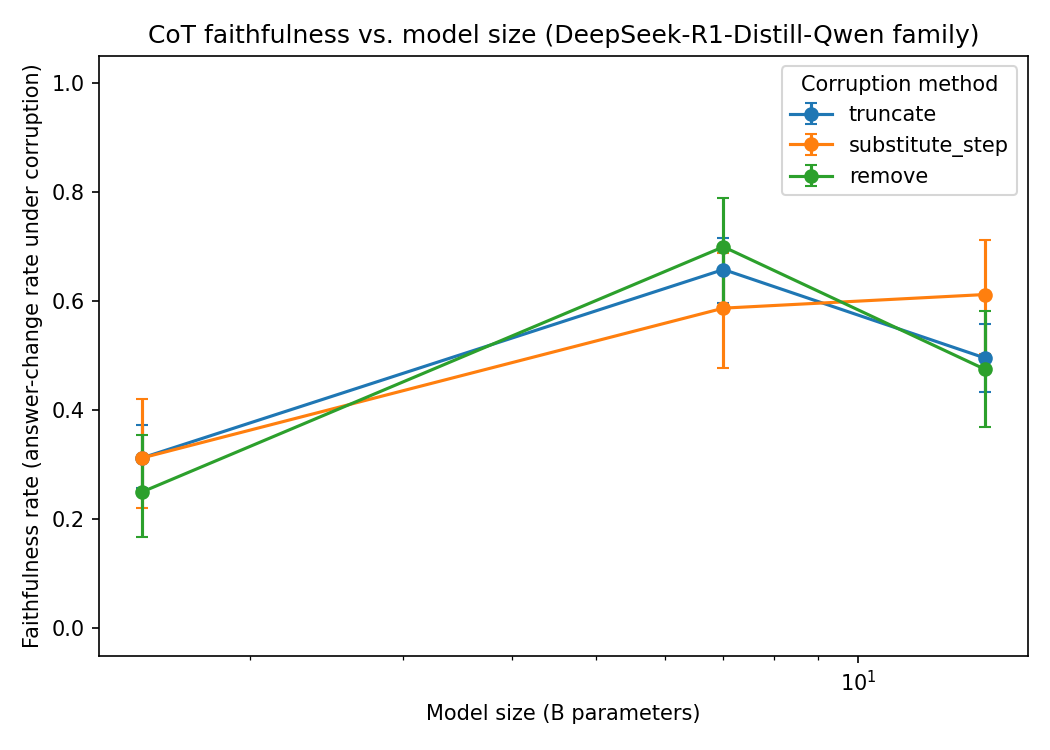

NOTE: the title above is plot_scaling_curve()'s fixed title, written for real results -- this specific figure is 100% synthetic (DemoScalingBackend), not a finding about the real model family.


In [5]:
from pipeline.scoring import plot_scaling_curve

out_path = "../results/mock_demo_scaling_curve.png"
plot_scaling_curve(all_results, DEMO_SIZES_B, out_path)
display(Image(filename=out_path))
print(
    "NOTE: the title above is plot_scaling_curve()'s fixed title, written for "
    "real results -- this specific figure is 100% synthetic (DemoScalingBackend), "
    "not a finding about the real model family."
)


## Next steps (once real inference is unblocked)

1. In `NEEDS_YOUR_INPUT.md`, get the hosted-API provider + key decision
   resolved and fill in `HostedAPIBackend._call_api` in
   `pipeline/inference.py`.
2. In this notebook: replace `make_synthetic_problems(...)` with
   `pipeline.data.load_gsm8k(split="test", n=...)`, and replace
   `DemoScalingBackend(...)` with three `HostedAPIBackend(model_name=...)`
   instances for the real DeepSeek-R1-Distill-Qwen-{1.5B,7B,14B} names.
3. Nothing else changes -- `run_experiment`, `summarize`, and
   `plot_scaling_curve` are already provider-agnostic and were exercised
   end-to-end above.
4. Once real results exist, save the real plot as `results/scaling_curve.png`
   (not the `mock_demo_` prefix used here) and fold the results table into
   `README.md`'s Results section.
